# MACHINE LEARNING PROJECT FINAL

## Initiation

### Import Section

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Read files

In [32]:
df_new = pd.read_csv("new_file_lending.csv")

# Data Understanding

In [33]:
# Dataset Overview

print("Dataset Shape:")
print(df_new.shape)

print("\nFirst 5 Rows:")
print(df_new.head())

print("\nDataset Info:")
print(df_new.info())

print("\nStatistical Summary:")
print(df_new.describe())

Dataset Shape:
(10000, 27)

First 5 Rows:
   loan_amnt        term  int_rate  installment grade sub_grade  \
0    10000.0   36 months     11.44       329.48     B        B4   
1     8000.0   36 months     11.99       265.68     B        B5   
2    15600.0   36 months     10.49       506.97     B        B3   
3     7200.0   36 months      6.49       220.65     A        A2   
4    24375.0   60 months     17.27       609.33     C        C5   

                 emp_title emp_length home_ownership  annual_inc  ...  \
0                Marketing  10+ years           RENT    117000.0  ...   
1          Credit analyst     4 years       MORTGAGE     65000.0  ...   
2             Statistician   < 1 year           RENT     43057.0  ...   
3          Client Advocate    6 years           RENT     54000.0  ...   
4  Destiny Management Inc.    9 years       MORTGAGE     55000.0  ...   

  open_acc pub_rec revol_bal revol_util total_acc  initial_list_status  \
0     16.0     0.0   36369.0       41.8   

# Exploratory Data Analysis (EDA)

## Histogram Distribusi Loan Amount

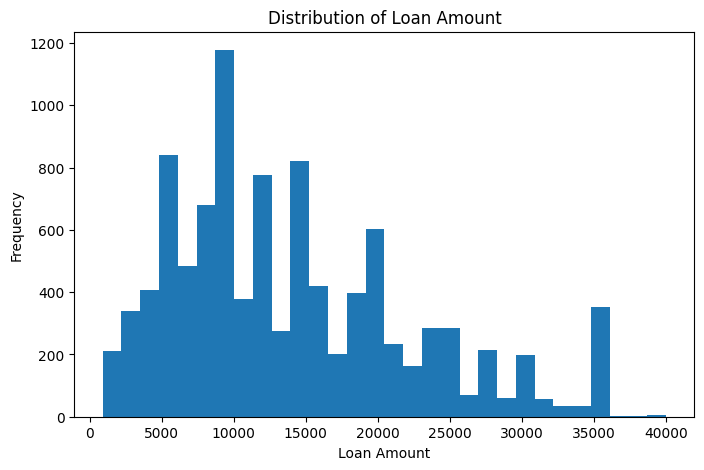

In [34]:
# ==================================================
# EDA 1: Loan Amount Distribution
# ==================================================

plt.figure(figsize=(8,5))
plt.hist(df_new['loan_amnt'], bins=30)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

## Boxplot Interest Rate

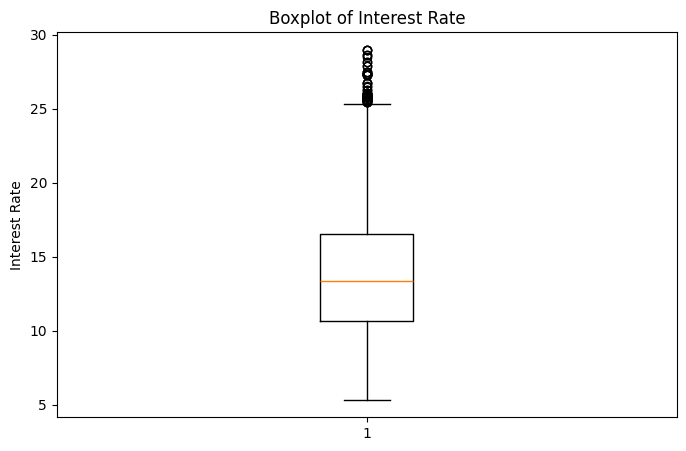

In [35]:
# ==================================================
# EDA 2: Interest Rate Outlier Detection
# ==================================================

plt.figure(figsize=(8,5))

plt.boxplot(df_new['int_rate'])

plt.title('Boxplot of Interest Rate')
plt.ylabel('Interest Rate')

plt.show()

## Bar Chart Loan Status

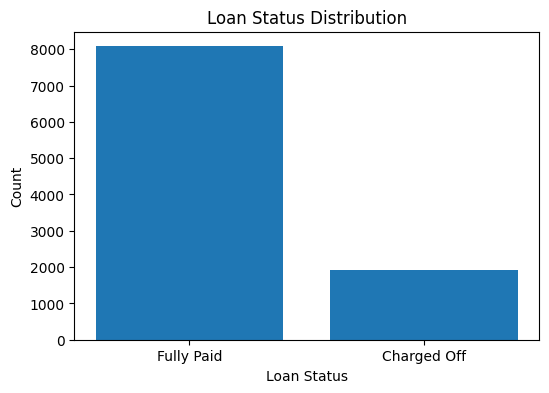

loan_status
Fully Paid     80.79
Charged Off    19.21
Name: proportion, dtype: float64


In [36]:
# ==================================================
# EDA 3: Loan Status Distribution
# ==================================================

loan_counts = df_new['loan_status'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    loan_counts.index.astype(str),
    loan_counts.values
)

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

print(df_new['loan_status'].value_counts(normalize=True)*100)

## Correlation Heatmap

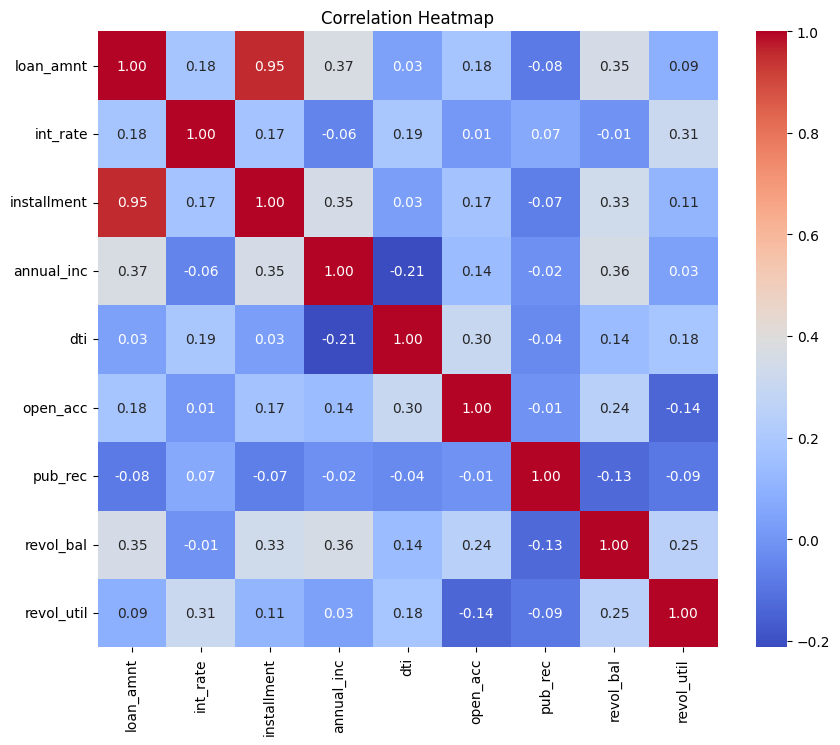

In [37]:
# ==================================================
# EDA 4: Correlation Heatmap
# ==================================================

numerical_cols = [
    'loan_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df_new[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## PREPROCESSING

### Memilih 10.000 data pertama dari data set yang dipilih

In [38]:
df = pd.read_csv("lending_club_loan_two.csv")
df_new = df.head(10000)

df_new.to_csv("new_file_lending.csv", index=False)

### Handle Missing Values

In [39]:
missing = df_new.isnull().sum()

print(missing.to_string())

loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
emp_title               585
emp_length              464
home_ownership            0
annual_inc                0
verification_status       0
issue_d                   0
loan_status               0
purpose                   0
title                    42
dti                       0
earliest_cr_line          0
open_acc                  0
pub_rec                   0
revol_bal                 0
revol_util                5
total_acc                 0
initial_list_status       0
application_type          0
mort_acc                901
pub_rec_bankruptcies     12
address                   0


In [40]:
df_new['emp_title'] = df_new['emp_title'].fillna(df_new['emp_title'].mode()[0])
df_new['title'] = df_new['title'].fillna(df_new['title'].mode()[0])
df_new['mort_acc'] = df_new['mort_acc'].fillna(df_new['mort_acc'].mode()[0])
df_new['pub_rec_bankruptcies'] = df_new['pub_rec_bankruptcies'].fillna(df_new['pub_rec_bankruptcies'].mode()[0])
df_new['emp_length'] = df_new['emp_length'].fillna(df_new['emp_length'].mode()[0])
df_new['revol_util'] = df_new['revol_util'].fillna(df_new['revol_util'].mode()[0])

In [41]:
missing = df_new.isnull().sum()

print(missing.to_string())

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
emp_title               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
title                   0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0


### Check Data Distribution

In [42]:
print(df_new['loan_status'].value_counts(normalize=True)*100)

loan_status
Fully Paid     80.79
Charged Off    19.21
Name: proportion, dtype: float64


### Feature Engineering - Extract & Create New Features


In [43]:
# Feature Engineering - Extract valuable information dari kolom date dan categorical

# 1. Ekstrak credit history age dari earliest_cr_line (tanggal pertama pembukaan akun kredit)
df_new['earliest_cr_line'] = pd.to_datetime(df_new['earliest_cr_line'], format='%b-%Y')
df_new['credit_history_age_months'] = (pd.to_datetime('2015-12') - df_new['earliest_cr_line']).dt.days // 30
# Feature ini penting: semakin lama history kredit, semakin terpercaya peminjam

# 2. Ekstrak informasi dari issue_d (tanggal pinjaman disetujui)
df_new['issue_d'] = pd.to_datetime(df_new['issue_d'], format='%b-%Y')
df_new['issue_month'] = df_new['issue_d'].dt.month
df_new['issue_year'] = df_new['issue_d'].dt.year
# Bulan/tahun mungkin berpengaruh terhadap status pinjaman

# 3. Handle title column - simplify dengan frequency-based grouping
# Kolom title memiliki 48k unique values, terlalu banyak untuk encoding
# Strategi: hanya ambil top categories yang muncul minimal 100x
title_counts = df_new['title'].value_counts()
top_titles = title_counts[title_counts >= 100].index.tolist()
df_new['title_simplified'] = df_new['title'].apply(lambda x: x if pd.notna(x) and x in top_titles else 'Other')
print(f"Title simplified ke {len(top_titles)} kategori (+ Other)")

# 4. Create binary feature untuk emp_title (ada employer title atau tidak)
# emp_title memiliki 173k unique values, terlalu banyak
# Solusi: hanya buat binary indicator apakah ada atau tidak
df_new['has_emp_title'] = (~df_new['emp_title'].isnull()).astype(int)

# 5. Create interaction features untuk meningkatkan model performance
# Kombinasi fitur yang mungkin lebih predictive daripada individual features
df_new['credit_to_income'] = df_new['credit_history_age_months'] / (df_new['annual_inc'] + 1)
# Rasio: peminjam dengan credit history lama tapi income rendah = risiko berbeda

df_new['loan_to_income'] = df_new['loan_amnt'] / (df_new['annual_inc'] + 1)
# Rasio pinjaman terhadap pendapatan tahunan - indicator kemampuan bayar

df_new['revol_util_to_income'] = df_new['revol_util'] / (df_new['annual_inc'] + 1)
# Penggunaan kredit revolving relatif terhadap income

df_new['total_monthly_payment'] = df_new['installment'] * 12
# Total pembayaran tahunan

print("\nFeature Engineering Summary:")
print(f" - Created 9 new features")
print(f" - Date-based features: credit_history_age_months, issue_month, issue_year")
print(f" - Categorical features: title_simplified, has_emp_title")
print(f" - Interaction features: credit_to_income, loan_to_income, revol_util_to_income, total_monthly_payment")
print(f" - Final modeling excluded issue_month and issue_year due to low predictive contribution")


Title simplified ke 6 kategori (+ Other)

Feature Engineering Summary:
 - Created 9 new features
 - Date-based features: credit_history_age_months, issue_month, issue_year
 - Categorical features: title_simplified, has_emp_title
 - Interaction features: credit_to_income, loan_to_income, revol_util_to_income, total_monthly_payment
 - Final modeling excluded issue_month and issue_year due to low predictive contribution


### Encoding

In [44]:
# Daftar kolom dengan tipe data object yang perlu diubah
categorical_cols = [
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'verification_status', 'purpose', 'application_type',
    'term', 'initial_list_status', 'title_simplified'
]

# One-Hot Encoding untuk fitur kategorikal
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_features = encoder.fit_transform(df_new[categorical_cols])

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(categorical_cols)
)

# Sanitasi nama kolom untuk XGBoost
encoded_df.columns = [
    str(col).replace('<', '_')
            .replace('>', '_')
            .replace('[', '_')
            .replace(']', '_')
    for col in encoded_df.columns
]

# Drop kolom kategorikal asli, lalu gabungkan dengan hasil encoding
df_new = df_new.drop(columns=categorical_cols).reset_index(drop=True)
df_new = pd.concat([df_new, encoded_df], axis=1)

# Sanitasi semua nama kolom dataset setelah encoding
df_new.columns = [
    str(col).replace('<', '_')
            .replace('>', '_')
            .replace('[', '_')
            .replace(']', '_')
    for col in df_new.columns
]

print("=== Encoding Summary ===")
print(f"Original Features : 27")
print(f"Final Features    : {df_new.shape[1]}")
print(f"Encoded Features  : {encoded_df.shape[1]}")

# Manual mapping untuk target credit scoring
# 0 = Fully Paid / tidak gagal bayar
# 1 = Charged Off / gagal bayar
df_new['loan_status'] = df_new['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

=== Encoding Summary ===
Original Features : 27
Final Features    : 114
Encoded Features  : 88


### Dataset Summary

In [45]:
# Summary statistik setelah semua preprocessing & feature engineering
print("=== Dataset Summary ===")
print(f"Shape: {df_new.shape}")
print(f"\nMissing values:")
print(df_new.isnull().sum()[df_new.isnull().sum() > 0])
print(f"\nTarget distribution:")
print(df_new['loan_status'].value_counts())


=== Dataset Summary ===
Shape: (10000, 114)

Missing values:
Series([], dtype: int64)

Target distribution:
loan_status
0    8079
1    1921
Name: count, dtype: int64


## Modeling

### Split Dataset (Holdout Validation)

In [46]:
# Train-test split dengan fitur engineering

# Drop kolom yang tidak perlu atau sudah di-extract:
# - 'loan_status': target
# - 'address': terlalu unik, tidak informatif, dan memiliki kardinalitas sangat tinggi
# - 'emp_title': terlalu unik
# - 'title': sudah di-extract sebagai title_simplified
# - 'issue_d': (sudah di-extract menjadi issue_month, issue_year)
# - 'issue_month' : kontribusi prediktif rendah berdasarkan hasil eksperimen feature importance
# - 'issue_year' : kontribusi prediktif rendah berdasarkan hasil eksperimen feature importance
# - 'earliest_cr_line': sudah di-extract menjadi credit_history_age_months

drop_cols = ['loan_status', 'address', 'emp_title', 'title', 'issue_d', 'issue_month', 'issue_year', 'earliest_cr_line']
X_lending = df_new.drop(columns=drop_cols, axis=1)
y_lending = df_new['loan_status']

X_train_lending, X_test_lending, y_train_lending, y_test_lending = train_test_split(
    X_lending,
    y_lending,
    test_size=0.2,
    random_state=42,
    stratify=y_lending
)

# Handling imbalanced data with SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE

# Cek distribusi sebelum SMOTE
print("Class Distribution Before SMOTE:")
print(y_train_lending.value_counts())

# SMOTE Oversampling
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_lending,
    y_train_lending
)

# Cek distribusi setelah SMOTE
print("\nClass Distribution After SMOTE:")
print(y_train_smote.value_counts())

# Cek ukuran data
print("\nTraining Data Shape Comparison")
print(f"Before SMOTE : {X_train_lending.shape}")
print(f"After SMOTE  : {X_train_smote.shape}")


Class Distribution Before SMOTE:
loan_status
0    6463
1    1537
Name: count, dtype: int64

Class Distribution After SMOTE:
loan_status
1    6463
0    6463
Name: count, dtype: int64

Training Data Shape Comparison
Before SMOTE : (8000, 106)
After SMOTE  : (12926, 106)


### Evaluation Metrics

In [47]:
def classification_metrics(prediction, y_test):
    accuracy = accuracy_score(y_test, prediction)
    f1 = f1_score(y_test, prediction, zero_division=0)
    recall = recall_score(y_test, prediction, zero_division=0)
    precision = precision_score(y_test, prediction, zero_division=0)

    print('Accuracy: ' + str(accuracy))
    print('F1 Score: ' + str(f1))
    print('Recall Score: ' + str(recall))
    print('Precision Score: ' + str(precision))

### MODEL 1: Decision Tree

In [48]:
# MODEL 1: Decision Tree

dtc_lending = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dtc_lending.fit(X_train_smote, y_train_smote)

# Prediksi data testing
prediction = dtc_lending.predict(X_test_lending)

# Evaluasi Decision Tree
print("Decision Tree Evaluation:")
classification_metrics(prediction, y_test_lending)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test_lending,
    prediction,
    digits=4
))

# Train dan Test Score
print("Train Score:", round(dtc_lending.score(X_train_smote, y_train_smote), 4))
print("Test Score:", round(dtc_lending.score(X_test_lending, y_test_lending), 4))

Decision Tree Evaluation:
Accuracy: 0.7755
F1 Score: 0.3348148148148148
Recall Score: 0.2942708333333333
Precision Score: 0.38831615120274915

Classification Report:
              precision    recall  f1-score   support

           0     0.8414    0.8899    0.8650      1616
           1     0.3883    0.2943    0.3348       384

    accuracy                         0.7755      2000
   macro avg     0.6149    0.5921    0.5999      2000
weighted avg     0.7544    0.7755    0.7632      2000

Train Score: 0.77
Test Score: 0.7755


### MODEL 2: Logistic Regression

In [49]:
# MODEL 2: Logistic Regression

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scaling khusus Logistic Regression
scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_lending_scaled = scaler.transform(X_test_lending)

# Training Logistic Regression
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic.fit(
    X_train_smote_scaled,
    y_train_smote
)

# Prediksi data testing
logistic_pred = logistic.predict(
    X_test_lending_scaled
)

# Evaluasi Logistic Regression
print("Logistic Regression Evaluation:")
classification_metrics(logistic_pred, y_test_lending)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test_lending,
    logistic_pred,
    digits=4
))

# Train dan Test Score
print("Train Score:", logistic.score(X_train_smote_scaled, y_train_smote))
print("Test Score:", logistic.score(X_test_lending_scaled, y_test_lending))

Logistic Regression Evaluation:
Accuracy: 0.653
F1 Score: 0.4226289517470882
Recall Score: 0.6614583333333334
Precision Score: 0.3105134474327628

Classification Report:
              precision    recall  f1-score   support

           0     0.8900    0.6510    0.7520      1616
           1     0.3105    0.6615    0.4226       384

    accuracy                         0.6530      2000
   macro avg     0.6003    0.6562    0.5873      2000
weighted avg     0.7788    0.6530    0.6887      2000

Train Score: 0.6713600495126102
Test Score: 0.653


### MODEL 3: XGBoost


In [50]:
from xgboost import XGBClassifier

# Training model XGBoost pada dataset lending
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
    verbosity=0
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test_lending)

print("XGBoost Evaluation:")
classification_metrics(xgb_pred, y_test_lending)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test_lending,
    xgb_pred,
    digits=4
))

print("Train score:", round(xgb_model.score(X_train_smote, y_train_smote),4))
print("Test score:", round(xgb_model.score(X_test_lending, y_test_lending),4))

XGBoost Evaluation:
Accuracy: 0.8015
F1 Score: 0.160676532769556
Recall Score: 0.09895833333333333
Precision Score: 0.42696629213483145

Classification Report:
              precision    recall  f1-score   support

           0     0.8189    0.9684    0.8874      1616
           1     0.4270    0.0990    0.1607       384

    accuracy                         0.8015      2000
   macro avg     0.6230    0.5337    0.5241      2000
weighted avg     0.7437    0.8015    0.7479      2000

Train score: 0.906
Test score: 0.8015


### Comparison Model DT, LR, XGB with CV


#### Initiation

In [51]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

#### Define Complete Evaluation

In [52]:
# =========================================================
# 11. Comparison Model DT, LR, XGB With CV - SMOTE Version
# =========================================================

results_summary = {}

def evaluate_model_comprehensive(model, X_train, X_test, y_train, y_test, model_name):
    
    # 1. SIMPLE TRAIN-TEST (tanpa CV)
    print("\n[1] SIMPLE TRAIN-TEST EVALUATION")
    print("-" * 50)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    print(f"Training Score (Accuracy): {train_score:.4f}")
    print(f"Testing Score (Accuracy):  {test_score:.4f}")
    
    # Detect overfitting/underfitting
    diff = train_score - test_score
    if diff > 0.05:
        status = "OVERFIT (Train >> Test)"
    elif train_score < 0.6 and test_score < 0.6:
        status = "UNDERFIT (Low both)"
    else:
        status = "STABLE (Good generalization)"
    print(f"Status: {status}")
    
    # 2. PREDICTIONS & METRICS
    print("\n[2] DETAILED EVALUATION METRICS")
    print("-" * 50)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    
    # Test metrics
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    
    print("TEST SET METRICS:")
    print(f"  Accuracy:  {acc_test:.4f}")
    print(f"  Precision: {prec_test:.4f}")
    print(f"  Recall:    {rec_test:.4f}")
    print(f"  F1 Score:  {f1_test:.4f}")
    
    # Train metrics
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)
    
    print("\nTRAIN SET METRICS:")
    print(f"  Accuracy:  {acc_train:.4f}")
    print(f"  Precision: {prec_train:.4f}")
    print(f"  Recall:    {rec_train:.4f}")
    print(f"  F1 Score:  {f1_train:.4f}")
    
    # 3. CROSS VALIDATION (5-Fold Stratified)
    print("\n[3] CROSS VALIDATION (5-Fold Stratified)")
    print("-" * 50)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_metrics = cross_validate(
        model, X_train, y_train, 
        cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        return_train_score=True
    )
    
    print("CV RESULTS (5-Fold):")
    print(f"  Train Accuracy: {cv_metrics['train_accuracy'].mean():.4f} (+/- {cv_metrics['train_accuracy'].std():.4f})")
    print(f"  Test Accuracy:  {cv_metrics['test_accuracy'].mean():.4f} (+/- {cv_metrics['test_accuracy'].std():.4f})")
    print(f"  Train F1:       {cv_metrics['train_f1'].mean():.4f} (+/- {cv_metrics['train_f1'].std():.4f})")
    print(f"  Test F1:        {cv_metrics['test_f1'].mean():.4f} (+/- {cv_metrics['test_f1'].std():.4f})")
    
    # Confusion Matrix
    print("\n[4] CONFUSION MATRIX (Test Set)")
    print("-" * 50)
    cm = confusion_matrix(y_test, y_pred_test)
    print(cm)
    print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")
    
    # Store results
    results_summary[model_name] = {
        'train_score': train_score,
        'test_score': test_score,
        'accuracy_train': acc_train,
        'accuracy_test': acc_test,
        'precision_test': prec_test,
        'recall_test': rec_test,
        'f1_test': f1_test,
        'cv_accuracy_mean': cv_metrics['test_accuracy'].mean(),
        'cv_accuracy_std': cv_metrics['test_accuracy'].std(),
        'cv_recall_mean': cv_metrics['test_recall'].mean(),
        'cv_f1_mean': cv_metrics['test_f1'].mean(),
        'status': status
    }

#### Decision Tree

In [53]:
# =========================================================
# Decision Tree with SMOTE
# =========================================================

dtc_comprehensive = DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    )

dtc_comprehensive.fit(X_train_smote, y_train_smote)

evaluate_model_comprehensive(
    dtc_comprehensive,
    X_train_smote,
    X_test_lending,
    y_train_smote,
    y_test_lending,
    "Decision Tree"
)


[1] SIMPLE TRAIN-TEST EVALUATION
--------------------------------------------------
Training Score (Accuracy): 0.7700
Testing Score (Accuracy):  0.7755
Status: STABLE (Good generalization)

[2] DETAILED EVALUATION METRICS
--------------------------------------------------
TEST SET METRICS:
  Accuracy:  0.7755
  Precision: 0.3883
  Recall:    0.2943
  F1 Score:  0.3348

TRAIN SET METRICS:
  Accuracy:  0.7700
  Precision: 0.8569
  Recall:    0.6483
  F1 Score:  0.7381

[3] CROSS VALIDATION (5-Fold Stratified)
--------------------------------------------------
CV RESULTS (5-Fold):
  Train Accuracy: 0.7610 (+/- 0.0122)
  Test Accuracy:  0.7595 (+/- 0.0099)
  Train F1:       0.7447 (+/- 0.0072)
  Test F1:        0.7430 (+/- 0.0125)

[4] CONFUSION MATRIX (Test Set)
--------------------------------------------------
[[1438  178]
 [ 271  113]]
  TN: 1438, FP: 178
  FN: 271, TP: 113


#### Logistic Regression

In [54]:
# =========================================================
# Logistic Regression with SMOTE
# =========================================================

scaler_comprehensive = StandardScaler()

X_train_smote_scaled_cv = scaler_comprehensive.fit_transform(X_train_smote)
X_test_lending_scaled_cv = scaler_comprehensive.transform(X_test_lending)

logistic_comprehensive = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_comprehensive.fit(X_train_smote_scaled_cv, y_train_smote)

evaluate_model_comprehensive(
    logistic_comprehensive,
    X_train_smote_scaled_cv,
    X_test_lending_scaled_cv,
    y_train_smote,
    y_test_lending,
    "Logistic Regression"
)


[1] SIMPLE TRAIN-TEST EVALUATION
--------------------------------------------------
Training Score (Accuracy): 0.6714
Testing Score (Accuracy):  0.6530
Status: STABLE (Good generalization)

[2] DETAILED EVALUATION METRICS
--------------------------------------------------
TEST SET METRICS:
  Accuracy:  0.6530
  Precision: 0.3105
  Recall:    0.6615
  F1 Score:  0.4226

TRAIN SET METRICS:
  Accuracy:  0.6714
  Precision: 0.6660
  Recall:    0.6875
  F1 Score:  0.6766

[3] CROSS VALIDATION (5-Fold Stratified)
--------------------------------------------------
CV RESULTS (5-Fold):
  Train Accuracy: 0.6724 (+/- 0.0018)
  Test Accuracy:  0.6671 (+/- 0.0064)
  Train F1:       0.6779 (+/- 0.0016)
  Test F1:        0.6724 (+/- 0.0083)

[4] CONFUSION MATRIX (Test Set)
--------------------------------------------------
[[1052  564]
 [ 130  254]]
  TN: 1052, FP: 564
  FN: 130, TP: 254


#### XGBoost

In [55]:
# =========================================================
# XGBoost with SMOTE
# =========================================================

xgb_comprehensive = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
    verbosity=0
)

xgb_comprehensive.fit(X_train_smote, y_train_smote)

evaluate_model_comprehensive(
    xgb_comprehensive,
    X_train_smote,
    X_test_lending,
    y_train_smote,
    y_test_lending,
    "XGBoost"
)


[1] SIMPLE TRAIN-TEST EVALUATION
--------------------------------------------------
Training Score (Accuracy): 0.9060
Testing Score (Accuracy):  0.8015
Status: OVERFIT (Train >> Test)

[2] DETAILED EVALUATION METRICS
--------------------------------------------------
TEST SET METRICS:
  Accuracy:  0.8015
  Precision: 0.4270
  Recall:    0.0990
  F1 Score:  0.1607

TRAIN SET METRICS:
  Accuracy:  0.9060
  Precision: 0.9918
  Recall:    0.8188
  F1 Score:  0.8970

[3] CROSS VALIDATION (5-Fold Stratified)
--------------------------------------------------
CV RESULTS (5-Fold):
  Train Accuracy: 0.9121 (+/- 0.0015)
  Test Accuracy:  0.8778 (+/- 0.0041)
  Train F1:       0.9045 (+/- 0.0018)
  Test F1:        0.8657 (+/- 0.0047)

[4] CONFUSION MATRIX (Test Set)
--------------------------------------------------
[[1565   51]
 [ 346   38]]
  TN: 1565, FP: 51
  FN: 346, TP: 38


### Comparison Summary


KEY METRICS COMPARISON:
                    train_score test_score accuracy_test precision_test recall_test   f1_test
Decision Tree          0.769998     0.7755        0.7755       0.388316    0.294271  0.334815
Logistic Regression     0.67136      0.653         0.653       0.310513    0.661458  0.422629
XGBoost                0.906003     0.8015        0.8015       0.426966    0.098958  0.160677


CROSS VALIDATION RESULTS:
                    cv_accuracy_mean cv_accuracy_std cv_recall_mean cv_f1_mean
Decision Tree               0.759477        0.009871       0.698114   0.742959
Logistic Regression         0.667104        0.006354       0.683579   0.672444
XGBoost                     0.877766         0.00407       0.788181   0.865729


OVERFIT/UNDERFIT STATUS:
  Decision Tree: STABLE (Good generalization)
  Logistic Regression: STABLE (Good generalization)
  XGBoost: OVERFIT (Train >> Test)


BEST MODELS BY METRIC:
  Highest Test Accuracy: XGBoost (0.8015)
  Highest Test Recall:   Log

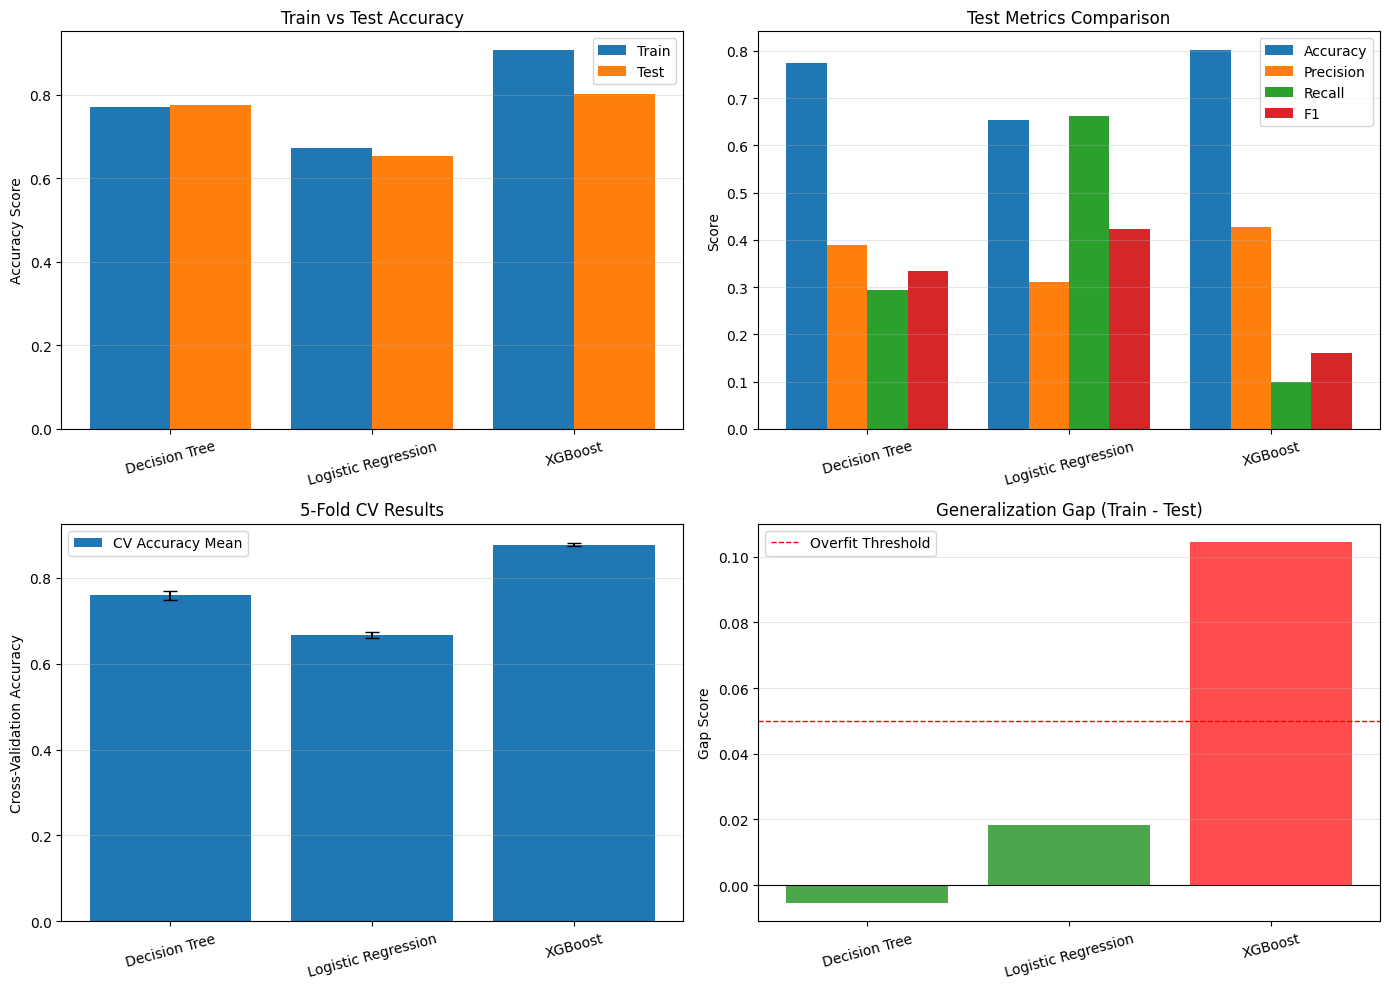

In [56]:
# =========================================================
# 12. Comparison Summary - SMOTE Version
# =========================================================

comparison_df = pd.DataFrame(results_summary).T

print("\nKEY METRICS COMPARISON:")
print(
    comparison_df[
        [
            'train_score',
            'test_score',
            'accuracy_test',
            'precision_test',
            'recall_test',
            'f1_test'
        ]
    ].to_string()
)

print("\n\nCROSS VALIDATION RESULTS:")
cv_df = comparison_df[
    [
        'cv_accuracy_mean',
        'cv_accuracy_std',
        'cv_recall_mean',
        'cv_f1_mean'
    ]
]

print(cv_df.to_string())

print("\n\nOVERFIT/UNDERFIT STATUS:")
for model_name, status in comparison_df['status'].items():
    print(f"  {model_name}: {status}")

print("\n\nBEST MODELS BY METRIC:")
print(
    f"  Highest Test Accuracy: {comparison_df['accuracy_test'].idxmax()} "
    f"({comparison_df['accuracy_test'].max():.4f})"
)

print(
    f"  Highest Test Recall:   {comparison_df['recall_test'].idxmax()} "
    f"({comparison_df['recall_test'].max():.4f})"
)

print(
    f"  Highest CV Recall:     {comparison_df['cv_recall_mean'].idxmax()} "
    f"({comparison_df['cv_recall_mean'].max():.4f})"
)

print(
    f"  Highest Test F1:       {comparison_df['f1_test'].idxmax()} "
    f"({comparison_df['f1_test'].max():.4f})"
)

print(
    f"  Best CV Stability:     {comparison_df['cv_accuracy_std'].idxmin()} "
    f"(std: {comparison_df['cv_accuracy_std'].min():.4f})"
)

# Visual Comparison 2x2

import matplotlib.pyplot as plt

models = comparison_df.index
x = range(len(models))
width = 0.2

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Train vs Test Accuracy
ax = axes[0, 0]
ax.bar([i - 0.2 for i in x], comparison_df['train_score'], width=0.4, label='Train')
ax.bar([i + 0.2 for i in x], comparison_df['test_score'], width=0.4, label='Test')
ax.set_title('Train vs Test Accuracy')
ax.set_ylabel('Accuracy Score')
ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Test Metrics Comparison
ax = axes[0, 1]
metrics = ['accuracy_test', 'precision_test', 'recall_test', 'f1_test']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']

for i, metric in enumerate(metrics):
    ax.bar(
        [j + i * width for j in x],
        comparison_df[metric],
        width,
        label=metric_names[i]
    )

ax.set_title('Test Metrics Comparison')
ax.set_ylabel('Score')
ax.set_xticks([i + 1.5 * width for i in x])
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. 5-Fold Cross Validation Results
ax = axes[1, 0]
ax.bar(
    list(x),
    comparison_df['cv_accuracy_mean'],
    yerr=comparison_df['cv_accuracy_std'],
    capsize=5,
    label='CV Accuracy Mean'
)
ax.set_title('5-Fold CV Results')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Generalization Gap
ax = axes[1, 1]
generalization_gap = comparison_df['train_score'] - comparison_df['test_score']

colors = [
    'red' if gap > 0.05 else 'green'
    for gap in generalization_gap
]

ax.bar(models, generalization_gap, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1, label='Overfit Threshold')
ax.set_title('Generalization Gap (Train - Test)')
ax.set_ylabel('Gap Score')
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance

## Decision Tree

Top 10 Decision Tree Feature Importance:
                            Feature  Importance
                            grade_C      0.4293
                           int_rate      0.3019
                            grade_D      0.2526
verification_status_Source Verified      0.0162
                        installment      0.0000
                         annual_inc      0.0000
                            pub_rec      0.0000
                          revol_bal      0.0000
                                dti      0.0000
                           open_acc      0.0000


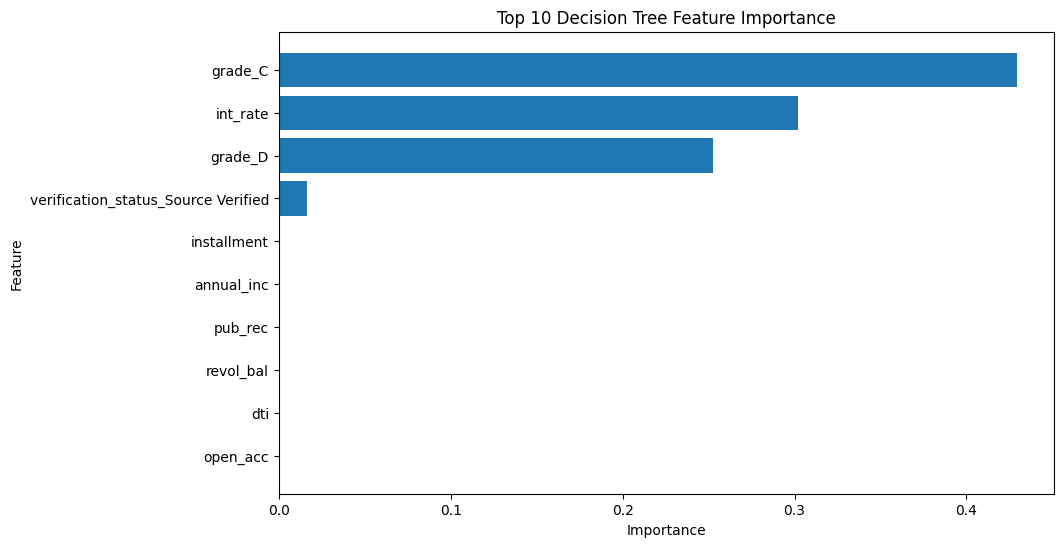

In [57]:
# Feature Importance with Decision Tree
importance_dt = dtc_lending.feature_importances_

feature_importance_dt = pd.DataFrame({
    'Feature': X_train_lending.columns,
    'Importance': importance_dt
}).sort_values(by='Importance', ascending=False)

# Output tabel Top 10 Feature Importance
print("Top 10 Decision Tree Feature Importance:")
print(feature_importance_dt.head(10).round(4).to_string(index=False))

# Grafik Top 10 Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_dt['Feature'].head(10),
    feature_importance_dt['Importance'].head(10)
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## Logistic Regression

Top 10 Logistic Regression Coefficient Importance:
             Feature  Coefficient  Importance
home_ownership_OTHER       0.2793      0.2793
             grade_A      -0.2363      0.2363
           loan_amnt      -0.1802      0.1802
            int_rate      -0.1637      0.1637
    credit_to_income       0.1619      0.1619
            open_acc       0.1488      0.1488
          revol_util       0.1487      0.1487
 purpose_educational      -0.1448      0.1448
             grade_D       0.1435      0.1435
     term_ 36 months      -0.1338      0.1338


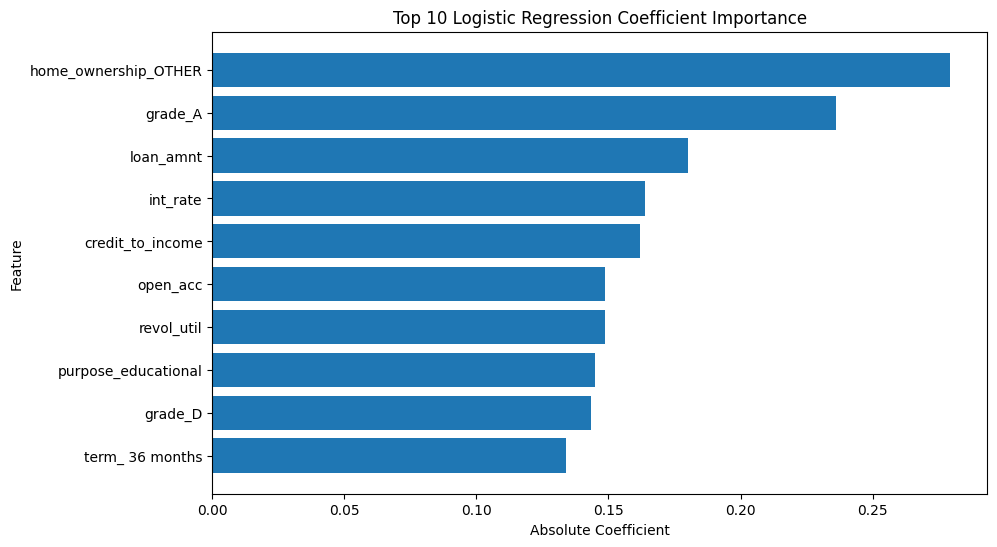

In [58]:
# Logistic Regression Coefficient Importance

coef = logistic.coef_[0]

feature_importance_lr = pd.DataFrame({
    'Feature': X_train_lending.columns,
    'Coefficient': coef
})

# Ambil nilai absolut agar bisa diurutkan berdasarkan besar pengaruh
feature_importance_lr['Importance'] = abs(
    feature_importance_lr['Coefficient']
)

feature_importance_lr = feature_importance_lr.sort_values(
    by='Importance',
    ascending=False
)

# Tabel Top 10
print("Top 10 Logistic Regression Coefficient Importance:")
print(
    feature_importance_lr[
        ['Feature', 'Coefficient', 'Importance']
    ].head(10).round(4).to_string(index=False)
)

# Grafik Top 10
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_lr['Feature'].head(10),
    feature_importance_lr['Importance'].head(10)
)

plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Logistic Regression Coefficient Importance')
plt.gca().invert_yaxis()
plt.show()

## Confusion Matrix Untuk Logistic Regression Karena Model Terbaik

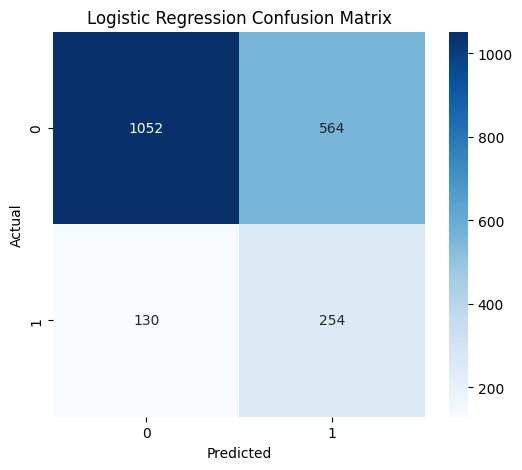

In [59]:
cm = confusion_matrix(
    y_test_lending,
    logistic_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

##### Confusion matrix menunjukkan bahwa Logistic Regression berhasil mendeteksi 254 kasus gagal bayar dan 1.052 kasus tidak gagal bayar dengan benar. Model menghasilkan 130 False Negative dan 564 False Positive, yang menunjukkan masih adanya kesalahan klasifikasi terutama pada prediksi risiko gagal bayar. Meskipun demikian, jumlah False Negative yang relatif rendah mendukung kemampuan model dalam mendeteksi peminjam berisiko sehingga sesuai untuk kasus credit scoring yang mengutamakan recall.

## XGBoost

Top 10 XGBoost Feature Importance:
                         Feature  Importance
                         grade_C      0.1090
         home_ownership_MORTGAGE      0.0941
           initial_list_status_w      0.0748
                         grade_D      0.0719
                         grade_B      0.0680
                 term_ 60 months      0.0667
                         grade_E      0.0484
          title_simplified_Other      0.0483
                         grade_A      0.0448
verification_status_Not Verified      0.0406


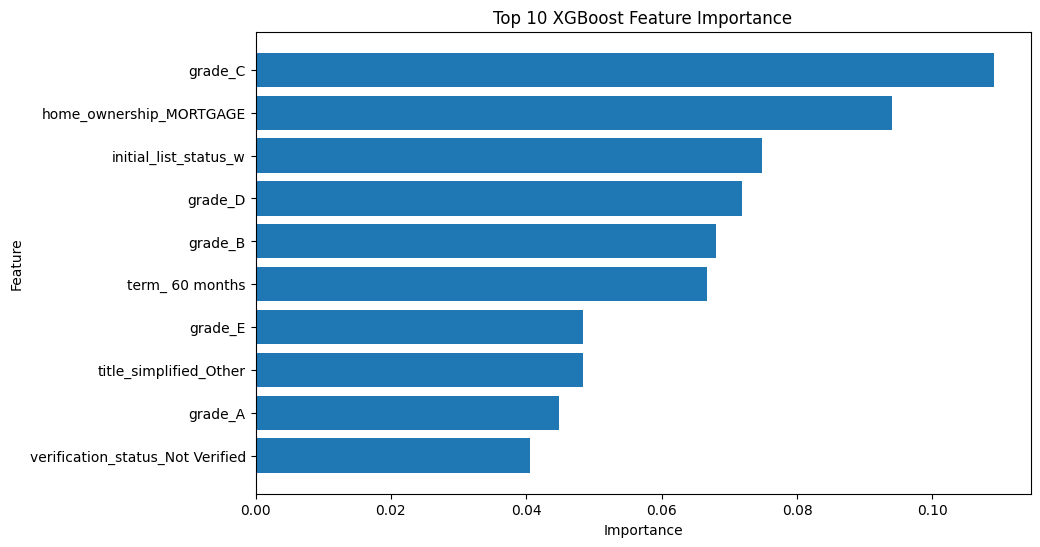

In [60]:
# Feature Importance with XGBoost
importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_lending.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Output tabel Top 10 Feature Importance
print("Top 10 XGBoost Feature Importance:")
print(feature_importance_df.head(10).round(4).to_string(index=False))

# Grafik Top 10 Feature Importance
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df['Feature'].head(10),
    feature_importance_df['Importance'].head(10)
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Kesimpulan

##### Berdasarkan hasil eksperimen yang telah dilakukan, seluruh model berhasil mempelajari pola pada data credit scoring dengan performa yang berbeda-beda. XGBoost memperoleh accuracy tertinggi sebesar 80,15%, namun menunjukkan recall yang rendah pada data testing dan indikasi overfitting. Logistic Regression menghasilkan recall tertinggi sebesar 66,14% dan F1-score tertinggi sebesar 42,26%, sehingga lebih efektif dalam mendeteksi peminjam yang berpotensi gagal bayar. Hasil cross-validation dan analisis generalisasi juga menunjukkan bahwa Logistic Regression memiliki performa yang lebih konsisten pada data baru. Oleh karena itu, Logistic Regression dipilih sebagai model terbaik untuk kasus credit scoring karena mampu memberikan keseimbangan yang baik antara kemampuan deteksi risiko, stabilitas model, dan interpretabilitas.